# Detecting Lanes using OpenCV

Pipeline: Edge Detection -> Region Masking -> Hough Transform -> Lane Overlay

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Create a Synthetic Road Image with Lane Lines

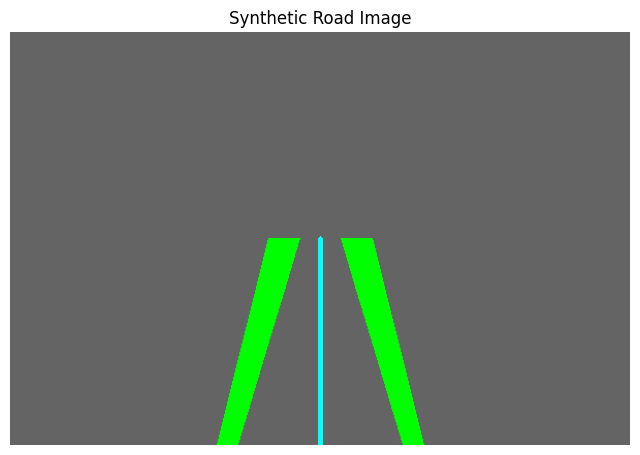

In [8]:
road = np.zeros((400, 600, 3), dtype=np.uint8)
road[:] = (100, 100, 100)

pts_left = np.array([[200, 400], [250, 200], [280, 200], [220, 400]], dtype=np.int32)
pts_right = np.array([[400, 400], [350, 200], [320, 200], [380, 400]], dtype=np.int32)
cv2.fillPoly(road, [pts_left], (0, 255, 0))
cv2.fillPoly(road, [pts_right], (0, 255, 0))
cv2.line(road, (300, 400), (300, 200), (255, 255, 0), 3)

plt.figure(figsize=(8, 6))
plt.imshow(road[..., ::-1])
plt.title('Synthetic Road Image')
plt.axis('off')
plt.show()

---
## Steps 1-3: Canny + ROI + Hough Transform (combined)

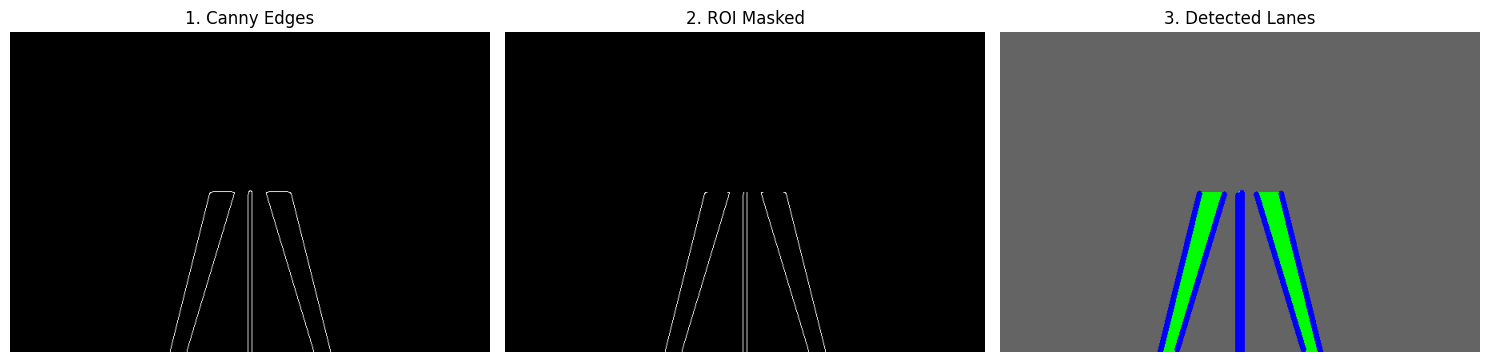

Lines detected: 6


In [9]:
def region_of_interest(img):
    h, w = img.shape
    mask = np.zeros_like(img)
    polygon = np.array([[(0, h), (w//3, h//2), (2*w//3, h//2), (w, h)]], dtype=np.int32)
    cv2.fillPoly(mask, polygon, 255)
    return cv2.bitwise_and(img, mask)

gray = cv2.cvtColor(road, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
masked_edges = region_of_interest(edges)

lines = cv2.HoughLinesP(masked_edges, rho=1, theta=np.pi/180,
                         threshold=20, minLineLength=20, maxLineGap=200)

line_img = road.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 5)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(edges, cmap='gray')
plt.title('1. Canny Edges')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(masked_edges, cmap='gray')
plt.title('2. ROI Masked')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(line_img[..., ::-1])
plt.title('3. Detected Lanes')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Lines detected: {len(lines) if lines is not None else 0}')

---
## Step 4: Full Pipeline with Lane Overlay

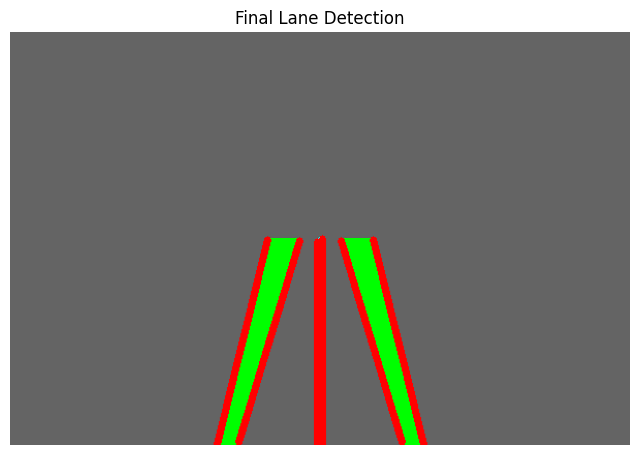

In [10]:
def detect_lanes(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    h, w = edges.shape
    mask = np.zeros_like(edges)
    polygon = np.array([[(0, h), (w//3, h//2), (2*w//3, h//2), (w, h)]], dtype=np.int32)
    cv2.fillPoly(mask, polygon, 255)
    masked = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(masked, 1, np.pi/180, 20, minLineLength=20, maxLineGap=200)
    result = img.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 5)
    return result

result = detect_lanes(road)

plt.figure(figsize=(8, 6))
plt.imshow(result[..., ::-1])
plt.title('Final Lane Detection')
plt.axis('off')
plt.show()

---
## Bonus: Try on a Real Image

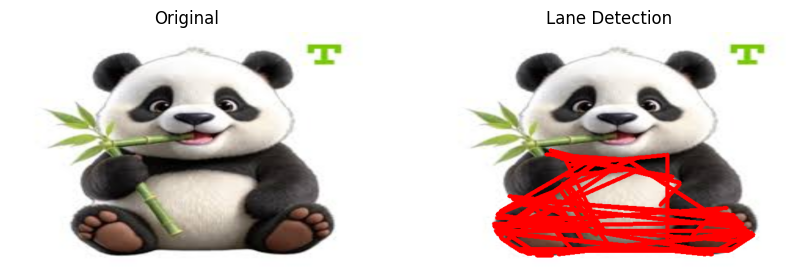

In [11]:
import os
img_dir = os.path.dirname(os.getcwd())
real_img = cv2.imread(os.path.join(img_dir, 'images.jpg'))
if real_img is not None:
    resized = cv2.resize(real_img, (600, 400))
    lane_result = detect_lanes(resized)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(resized[..., ::-1])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(lane_result[..., ::-1])
    plt.title('Lane Detection')
    plt.axis('off')
    plt.show()
else:
    print('No real image available - using synthetic road only')